# Vortrace Quick Start

This guide will take you through a simple example showing how to do a density projection and slice of a Voronoi mesh. The input data for this notebook comes from snapshot 22 of the `galaxy_merger_star_formation_3d` example in the public version of the [Arepo code](https://arepo-code.org/).

In [1]:
import numpy as np
import vortrace as vt
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py as h5

First we define a function which reads in an Arepo file, which is stored using the hdf5 file format. This would be replaced by user code interfacing or generating their needed data.

In [2]:
def read_arepo_snap(snapname):
    f = h5.File(snapname, mode='r')

    pos = np.array(f['PartType0']['Coordinates'])
    rho = np.array(f['PartType0']['Density'])
    mass = np.array(f['PartType0']['Masses'])
    vol = mass / rho
    BoxSize = f['Parameters'].attrs['BoxSize']

    f.close()

    return pos, rho, vol, BoxSize

Next, we actually load in the data and create a Projection Cloud object. This object stores the Voronoi mesh data and facilitates various operations over the dataset.

In [3]:
%%time
snapname = '../tests/test_data/galaxy_interaction.hdf5'
pos, rho, vol, BoxSize = read_arepo_snap(snapname)

L = 75.
pc = vt.ProjectionCloud(pos, rho, vol=vol, boundbox=[0., BoxSize, 0., BoxSize, 0., BoxSize])

CPU times: user 4.5 ms, sys: 2 ms, total: 6.5 ms
Wall time: 5.89 ms


Now, we define the parameters for the projection we would like to do. For this, we'll do a grid projection which is useful for making images of galaxies. We'll do a projection in the 'xy' plane and the 'xz' plane.

In [4]:
%%time
extent = [BoxSize / 2. - L / 2., BoxSize / 2. + L / 2.]
bounds = [0., BoxSize]
# npix = 512
npix = 256
center = [BoxSize/2., BoxSize/2., BoxSize/2.]

dat_xy = pc.grid_projection(extent, npix, bounds, None)
dat_xz = pc.grid_projection(extent, npix, bounds, center, proj='xz')

CPU times: user 2min 45s, sys: 115 ms, total: 2min 46s
Wall time: 5.94 s


Now, let's make a plot of this data.

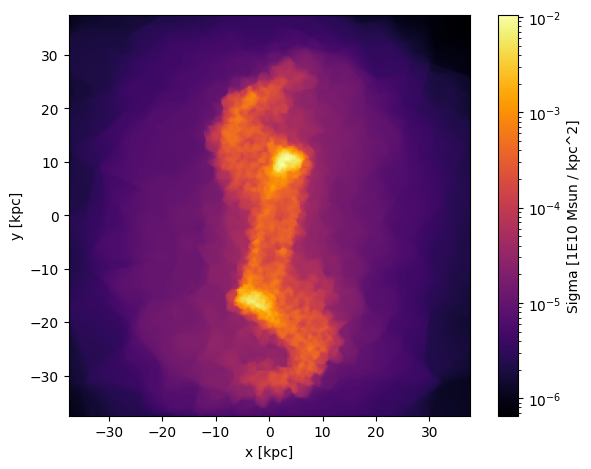

In [5]:
fig, ax, im = vt.plot.plot_grid(dat_xy, extent=[-L/2., L/2., -L/2., L/2.],
                               label='Sigma [1E10 Msun / kpc^2]')

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')

fig.tight_layout()
plt.show()

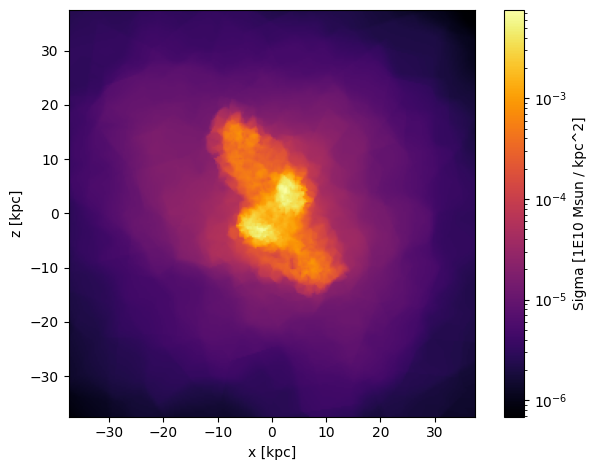

In [6]:
fig, ax, im = vt.plot.plot_grid(dat_xz, extent=[-L/2., L/2., -L/2., L/2.],
                               label='Sigma [1E10 Msun / kpc^2]')

ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')

fig.tight_layout()
plt.show()

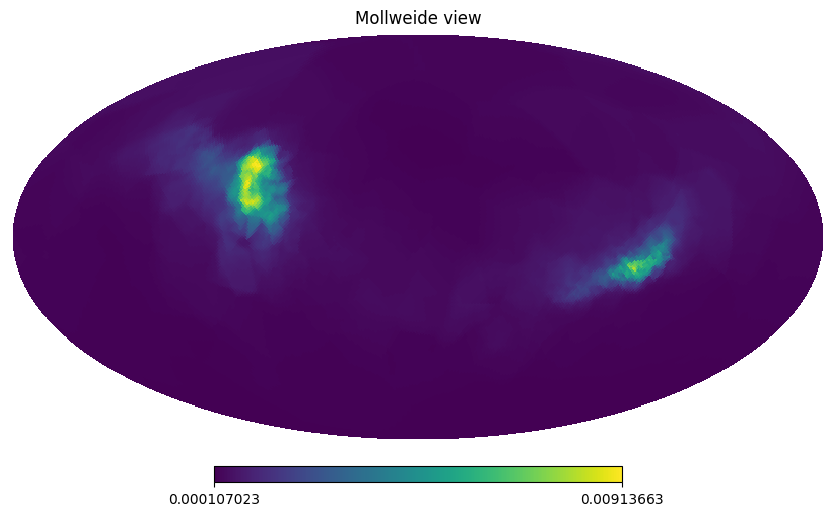

CPU times: user 27.8 s, sys: 79 ms, total: 27.9 s
Wall time: 1.61 s


In [7]:
%%time
import healpy as hp

### initialize the healpix grid and calculate the unit vectors towards each pixel
### the start position for each vector is the origin
nside = 64
npix = hp.nside2npix(nside)
res = hp.nside2resol(nside)

unitv = np.array(hp.pix2vec(nside=nside, ipix=np.arange(npix))).T
pts_end = 100*np.array(unitv)
pts_start = np.zeros_like(pts_end)

pts_start += BoxSize/2.
pts_end += BoxSize/2.

### do projection
dens = pc.projection(pts_start, pts_end)

### make plot
hp.mollview(dens)
plt.show()

We can also pull out all of the cells along the ray. Because the ray that is returned has a variable length that is determined at runtime, this can only be done one ray at a time.

In [8]:
%%time
pt_start = np.array([BoxSize/2. + 3, BoxSize/2. + 10.5, 0])
pt_end = np.array([BoxSize/2. + 3, BoxSize/2. + 10.5, BoxSize])

dens, cell_ids, s_vals, ds_vals = pc.single_projection(pt_start, pt_end)

CPU times: user 1.41 ms, sys: 1 μs, total: 1.41 ms
Wall time: 1.39 ms


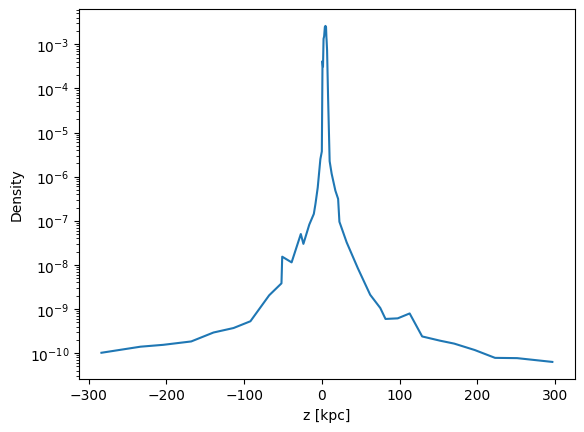

In [9]:
fig, ax = vt.plot.plot_ray(s_vals - BoxSize/2., rho[cell_ids])
ax.set_xlabel('z [kpc]')
ax.set_ylabel('Density')
plt.show()

## Multiple Fields

Vortrace can project multiple scalar fields simultaneously by passing a 2D array of shape `(N, nfields)`. This is especially useful for computing mass-weighted quantities. For example, to obtain a mass-weighted temperature map, project both density and density-weighted temperature, then take their ratio.

In [ ]:
# Create a multi-field cloud with density and density * temperature.
# We use a constant temperature T=42 so the recovered map should be uniform.
T_const = 42.0
fields_multi = np.column_stack([rho, rho * T_const])
print(f"Fields shape: {fields_multi.shape}  (N_particles x N_fields)")

pc_multi = vt.ProjectionCloud(
    pos, fields_multi, vol=vol,
    boundbox=[0., BoxSize, 0., BoxSize, 0., BoxSize])

In [ ]:
%%time
extent = [BoxSize / 2. - L / 2., BoxSize / 2. + L / 2.]
bounds = [0., BoxSize]
npix = 256

dat_multi = pc_multi.grid_projection(extent, npix, bounds, None)
print(f"Output shape: {dat_multi.shape}")  # (256, 256, 2)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ext = [-L/2., L/2., -L/2., L/2.]

# Field 0: column density
vt.plot.plot_grid(dat_multi[:, :, 0], extent=ext, ax=axes[0],
                  label=r'$\Sigma$ [1E10 Msun / kpc$^2$]')
axes[0].set_title('Column density')
axes[0].set_xlabel('x [kpc]')
axes[0].set_ylabel('y [kpc]')

# Field 1: density-weighted temperature integral
vt.plot.plot_grid(dat_multi[:, :, 1], extent=ext, ax=axes[1],
                  label=r'$\Sigma \cdot T$')
axes[1].set_title(r'$\int \rho \, T \, dl$')
axes[1].set_xlabel('x [kpc]')

# Ratio recovers mass-weighted temperature
T_map = dat_multi[:, :, 1] / dat_multi[:, :, 0]
vt.plot.plot_grid(T_map, extent=ext, ax=axes[2], log=False,
                  label='T')
axes[2].set_title('Mass-weighted T (= 42)')
axes[2].set_xlabel('x [kpc]')

fig.tight_layout()
plt.show()

The third panel recovers the constant temperature T=42, confirming that the multi-field projection is consistent. In a real simulation where temperature varies spatially, this technique produces a proper mass-weighted temperature map.

## Saving and Loading

Vortrace provides `vt.io` for saving/loading projection grids and point clouds. Both **npz** (default, zero extra deps) and **hdf5** formats are supported.

Loaded grid shape: (256, 256)
Metadata: {'projection': 'xy', 'npix': 256, 'extent': array([-37.5,  37.5, -37.5,  37.5])}


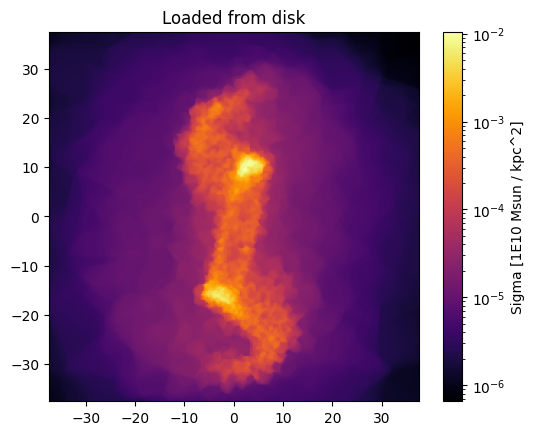

CPU times: user 367 ms, sys: 11 ms, total: 378 ms
Wall time: 375 ms


In [10]:
%%time
# Save a projection grid (npz)
vt.io.save_grid('/tmp/dat_xy.npz', dat_xy, extent=[-L/2., L/2., -L/2., L/2.],
                metadata={'projection': 'xy', 'npix': 256})

# Load it back
data, meta = vt.io.load_grid('/tmp/dat_xy.npz')
print('Loaded grid shape:', data.shape)
print('Metadata:', meta)

# Plot the loaded grid directly
fig, ax, im = vt.plot.plot_grid(data, extent=meta['extent'],
                               label='Sigma [1E10 Msun / kpc^2]')
ax.set_title('Loaded from disk')
plt.show()

In [11]:
%%time
# Save and reload the entire point cloud (KD-tree is rebuilt on load)
pc.save('/tmp/cloud.npz')
pc_loaded = vt.ProjectionCloud.load('/tmp/cloud.npz')
print('Reloaded cloud with', len(pc_loaded.fields_orig), 'particles')

Reloaded cloud with 7217 particles
CPU times: user 5 ms, sys: 2 μs, total: 5 ms
Wall time: 4.17 ms


## Periodic Boundary Conditions

Vortrace supports periodic boundary conditions, which is essential for cosmological simulation boxes where the domain wraps around. When `periodic=True`, the nearest-neighbor search checks periodic images of each query point, and no spatial filtering is applied — all particles are loaded.

Number of cells:  29452


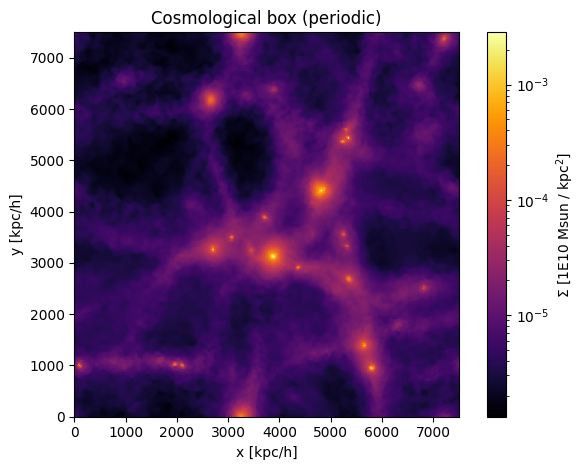

CPU times: user 2min 27s, sys: 34 ms, total: 2min 27s
Wall time: 5.37 s


In [12]:
%%time
snapname_cosmo = '../tests/test_data/cosmo_box.hdf5'
pos_cosmo, rho_cosmo, _vol_cosmo, BoxSize_cosmo = read_arepo_snap(snapname_cosmo)

print('Number of cells: ', len(pos_cosmo))

pc_cosmo = vt.ProjectionCloud(
    pos_cosmo, rho_cosmo,
    boundbox=[0., BoxSize_cosmo, 0., BoxSize_cosmo, 0., BoxSize_cosmo],
    periodic=True)

npix_cosmo = 256
extent_cosmo = [0., BoxSize_cosmo]
bounds_cosmo = [0., BoxSize_cosmo]

dat_cosmo = pc_cosmo.grid_projection(extent_cosmo, npix_cosmo, bounds_cosmo, None)

fig, ax, im = vt.plot.plot_grid(
    dat_cosmo,
    extent=[0., BoxSize_cosmo, 0., BoxSize_cosmo],
    label=r'$\Sigma$ [1E10 Msun / kpc$^2$]')
ax.set_xlabel('x [kpc/h]')
ax.set_ylabel('y [kpc/h]')
ax.set_title('Cosmological box (periodic)')
fig.tight_layout()
plt.show()